### Linear regression by using Deep Neural network:
#### Implement Boston housing price prediction problem by Linear regression using Deep Neural network.
#### Use Boston House price prediction dataset.

In [25]:
import pandas as pd
data = pd.read_csv("./HousingData.csv")

In [26]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [27]:
data.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [5]:
# Fills missing values in the 'rm' column with the mean of that column.
data.fillna(data.mean(), inplace=True)

In [6]:
data.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [9]:
# Separate input features and target variable

# X = independent variables
X = data.drop("MEDV", axis=1)

# y = dependent variable (house price)
y = data["MEDV"]

In [10]:
# Splits data into training and testing sets for model training and evaluation.

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y)

In [11]:
# Scale the feature values between 0 and 1 using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [28]:
# Create a neural network with:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(128, activation='relu'))      # One hidden layer (Dense(128) with ReLU activation).
model.add(Dense(1, activation='linear'))      # One output layer with a linear activation (for regression).

# Compiles the model
model.compile(loss='mae', optimizer='adam', metrics=['mse', 'mae'])

In [29]:
# Trains the model on the training data for 5 epochs

model.fit(x_train, y_train, epochs=50)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 22.0253 - mae: 22.0253 - mse: 564.5862
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 21.5853 - mae: 21.5853 - mse: 558.9603 
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.3486 - mae: 20.3486 - mse: 496.3814 
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.2582 - mae: 20.2582 - mse: 503.7166 
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.2908 - mae: 19.2908 - mse: 463.9667 
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 17.0640 - mae: 17.0640 - mse: 373.2063 
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16.3868 - mae: 16.3868 - mse: 362.3333 
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.0492 - mae: 14.0492 - mse: 281.3609 
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.7179 - mae: 12.7179 - mse: 240.1586 
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.4377 - mae: 12.4377 - mse: 241.3914 
Epoch 11/50
12/12 ━━

In [21]:
# Evaluates the model’s performance on the test data
metrics = model.evaluate(x_test, y_test)
metrics

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.6404 - mae: 4.6404 - mse: 48.1631 


[4.498563766479492, 43.89146423339844, 4.498563766479492]

In [30]:
# Use the trained model to make predictions on the test data
y_pred = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 


In [23]:
# Reshapes the actual target values for comparison with predictions (makes it a 2D array)
import numpy as np
y_test = np.array(y_test).reshape(-1, 1)

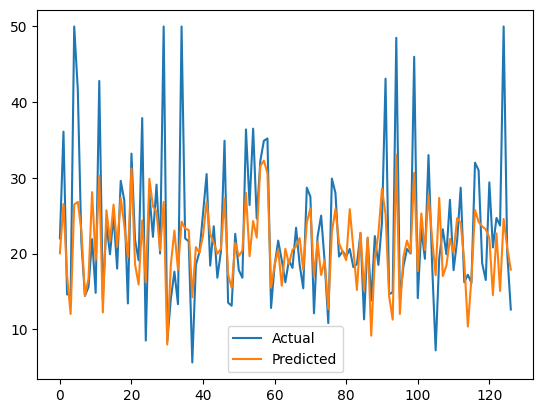

In [32]:
# Plots the actual vs predicted values of medv.

import matplotlib.pyplot as plt

plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()